# AI-Powered Credit Scoring Notebook
This notebook demonstrates end-to-end credit risk modeling using the `application_train.csv` dataset. It includes data loading, exploration, feature engineering, training, evaluation, and model export.

## 1. Setup
Install the required libraries and import core packages.

In [1]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: C:\Users\Manth\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
import sys
print(sys.executable)

C:\Users\Manth\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
import sys
!{sys.executable} -m pip install lightgbm


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: C:\Users\Manth\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,roc_curve,confusion_matrix
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier

In [5]:
df=pd.read_csv("application_train.csv")

In [6]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.shape

(307511, 122)

In [8]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [9]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [11]:
missing_values = df.isnull().sum()
missing_values

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

## 3. Exploratory data analysis
Visualize the target distribution and inspect key patterns in the dataset.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


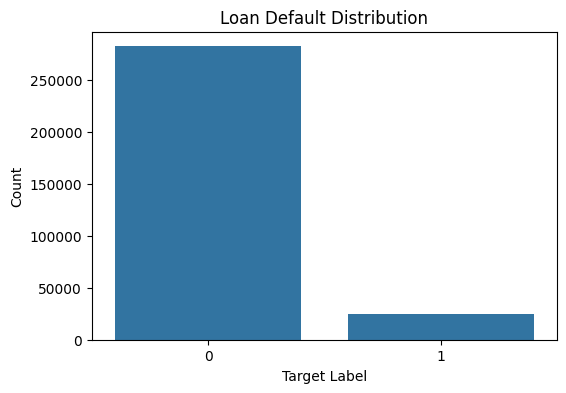

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df)
plt.title("Loan Default Distribution")
plt.xlabel("Target Label")
plt.ylabel("Count")
plt.show()

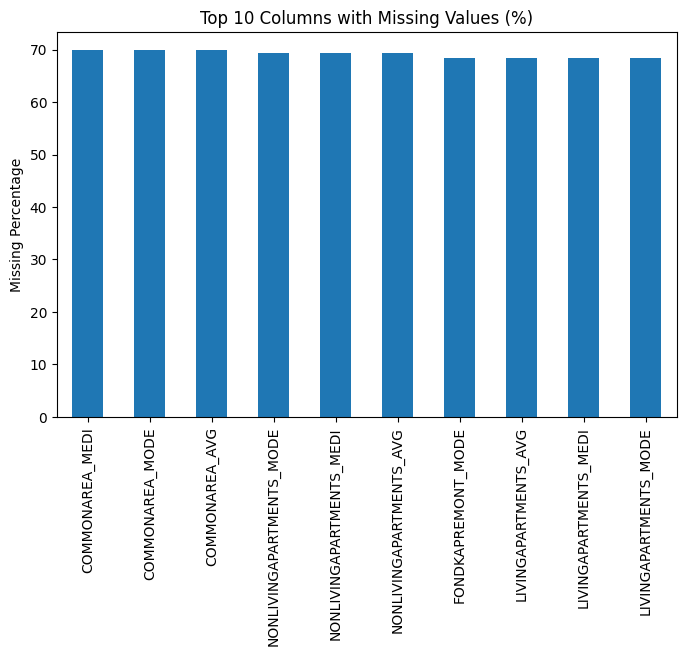

In [14]:
missing = df.isnull().mean()*100
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(8,5))
missing.head(10).plot(kind='bar')
plt.title("Top 10 Columns with Missing Values (%)")
plt.ylabel("Missing Percentage")
plt.show()

In [15]:
#Insight:
#Income distribution is similar for both defaulters and non-defaulters, with many outliers present. This indicates that income alone is not a strong predictor of loan default.

In [16]:
m = df.isnull().mean() * 100
m

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64

## 4. Data cleaning
Remove columns with too many missing values and drop identifier columns that are not predictive.

In [17]:
threshold = 50
protected_columns = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Keep trusted external source features, but remove columns with more than 50% missing values
m = df.isnull().mean() * 100
dropcol = [col for col in m[m > threshold].index if col not in protected_columns]
df.drop(columns=dropcol, inplace=True)

# Drop the identifier column to avoid data leakage into the model
df.drop(columns=['SK_ID_CURR'], inplace=True, errors='ignore')

df.shape

(307511, 81)

In [18]:
df

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Feature engineering and outlier detection
Create new derived features and inspect numerical data for extreme values.

In [19]:
df.shape

(307511, 81)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   TARGET                        307511 non-null  int64  
 1   NAME_CONTRACT_TYPE            307511 non-null  object 
 2   CODE_GENDER                   307511 non-null  object 
 3   FLAG_OWN_CAR                  307511 non-null  object 
 4   FLAG_OWN_REALTY               307511 non-null  object 
 5   CNT_CHILDREN                  307511 non-null  int64  
 6   AMT_INCOME_TOTAL              307511 non-null  float64
 7   AMT_CREDIT                    307511 non-null  float64
 8   AMT_ANNUITY                   307499 non-null  float64
 9   AMT_GOODS_PRICE               307233 non-null  float64
 10  NAME_TYPE_SUITE               306219 non-null  object 
 11  NAME_INCOME_TYPE              307511 non-null  object 
 12  NAME_EDUCATION_TYPE           307511 non-nul

In [21]:
# Create meaningful ratio features for credit risk assessment
df['CREDIT_INCOME_PERCENT'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_PERCENT'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
df['DAYS_EMPLOYED_PERCENT'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
df['EXT_SOURCES_AVG'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

df[['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT', 'EXT_SOURCES_AVG']].head()
# Display the newly created features for verification

,CREDIT_INCOME_PERCENT,ANNUITY_INCOME_PERCENT,CREDIT_TERM,DAYS_EMPLOYED_PERCENT,EXT_SOURCES_AVG
0,2.007889,0.121978,0.060749,0.067329,0.161787
1,4.790750,0.132217,0.027598,0.070862,0.466757
2,2.000000,0.100000,0.050000,0.011814,0.642739
3,2.316167,0.219900,0.094941,0.159905,0.650442
4,4.222222,0.179963,0.042623,0.152418,0.322738


In [22]:
# Identify columns that contain potential outliers based on the IQR rule
outlier_columns = []
for col in df.select_dtypes(include=['number']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    if ((df[col] < lower_bound) | (df[col] > upper_bound)).any():
        outlier_columns.append(col)

print(f"Columns containing potential outliers: {outlier_columns}")

Columns containing potential outliers: ['TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'YEARS_BEGINEXPLUATATION_AVG', 'FLOORSMAX_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'FLOORSMAX_MEDI', 'TOTALAREA_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG

In [23]:
df.describe()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_INCOME_PERCENT,ANNUITY_INCOME_PERCENT,CREDIT_TERM,DAYS_EMPLOYED_PERCENT,EXT_SOURCES_AVG
count,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,...,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,307511.000000,307499.000000,307499.000000,307511.000000,307339.000000
mean,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,...,0.007000,0.034362,0.267395,0.265474,1.899974,3.957570,0.180930,0.053695,-2.920135,0.509251
std,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,3522.886321,...,0.110757,0.204685,0.916002,0.794056,1.869295,2.689728,0.094574,0.022481,6.627098,0.149802
min,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,-24672.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.004808,0.000224,0.022073,-47.489663,0.000006
25%,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,-7479.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.018667,0.114782,0.036900,0.021559,0.413648
50%,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,-4504.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,3.265067,0.162833,0.050000,0.088645,0.524502
75%,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,-2010.000000,...,0.000000,0.000000,0.000000,0.000000,3.000000,5.159880,0.229067,0.064043,0.191000,0.622819
max,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,0.000000,...,9.000000,8.000000,27.000000,261.000000,25.000000,84.736842,1.875965,0.124430,0.728811,0.878903


In [24]:
df["DAYS_EMPLOYED"]

0           -637
1          -1188
2           -225
3          -3039
4          -3038
           ...  
307506      -236
307507    365243
307508     -7921
307509     -4786
307510     -1262
Name: DAYS_EMPLOYED, Length: 307511, dtype: int64

In [25]:
# Replace the placeholder value for unknown employment days with NaN
# This enables proper imputation later in the pipeline
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

## 6. Train/test split and preprocessing
Prepare training and testing sets, then define numeric and categorical preprocessing.

In [26]:
x = df.drop(["TARGET"], axis=1)
y = df["TARGET"]

In [27]:
x

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_INCOME_PERCENT,ANNUITY_INCOME_PERCENT,CREDIT_TERM,DAYS_EMPLOYED_PERCENT,EXT_SOURCES_AVG
0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,...,0.0,0.0,0.0,0.0,1.0,2.007889,0.121978,0.060749,0.067329,0.161787
1,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,...,0.0,0.0,0.0,0.0,0.0,4.790750,0.132217,0.027598,0.070862,0.466757
2,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,...,0.0,0.0,0.0,0.0,0.0,2.000000,0.100000,0.050000,0.011814,0.642739
3,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,...,NaN,NaN,NaN,NaN,NaN,2.316167,0.219900,0.094941,0.159905,0.650442
4,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,...,0.0,0.0,0.0,0.0,0.0,4.222222,0.179963,0.042623,0.152418,0.322738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Unaccompanied,...,NaN,NaN,NaN,NaN,NaN,1.617143,0.174971,0.108198,0.025303,0.413601
307507,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Unaccompanied,...,NaN,NaN,NaN,NaN,NaN,3.743750,0.166687,0.044524,-17.580890,0.115992
307508,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Unaccompanied,...,0.0,0.0,1.0,0.0,1.0,4.429176,0.195941,0.044239,0.529266,0.499536
307509,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,Unaccompanied,...,0.0,0.0,0.0,0.0,0.0,2.164368,0.118158,0.054592,0.400134,0.587593


In [28]:
y

0         1
1         0
2         0
3         0
4         0
         ..
307506    0
307507    0
307508    0
307509    1
307510    0
Name: TARGET, Length: 307511, dtype: int64

In [29]:
from sklearn.preprocessing import RobustScaler

In [30]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [31]:
catcols = x.select_dtypes(include=['object']).columns

In [32]:
numcols = x.select_dtypes(include=['number']).columns

In [33]:
numpipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [34]:
catpipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [35]:
preprocessor = ColumnTransformer([
    ('num',numpipeline,numcols),
    ('cat',catpipeline,catcols)
])

## 7. Model training and evaluation
Train candidate models and compare them using ROC-AUC.

In [36]:
from sklearn.pipeline import Pipeline

In [37]:
# Compute imbalance ratio for XGBoost weighting
scale_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1]))

In [38]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=2000),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_weight, random_state=42)
}

In [39]:
results = {}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(x_train, y_train)
    
    # Evaluate using ROC-AUC (better for imbalanced data than accuracy)[cite: 1]
    y_prob = pipe.predict_proba(x_test)[:, 1]
    score = roc_auc_score(y_test, y_prob)
    results[name] = {"pipeline": pipe, "score": score}
    print(f"{name} ROC-AUC: {score:.4f}")

C:\Users\Manth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression ROC-AUC: 0.7501
Random Forest ROC-AUC: 0.7351
XGBoost ROC-AUC: 0.7559


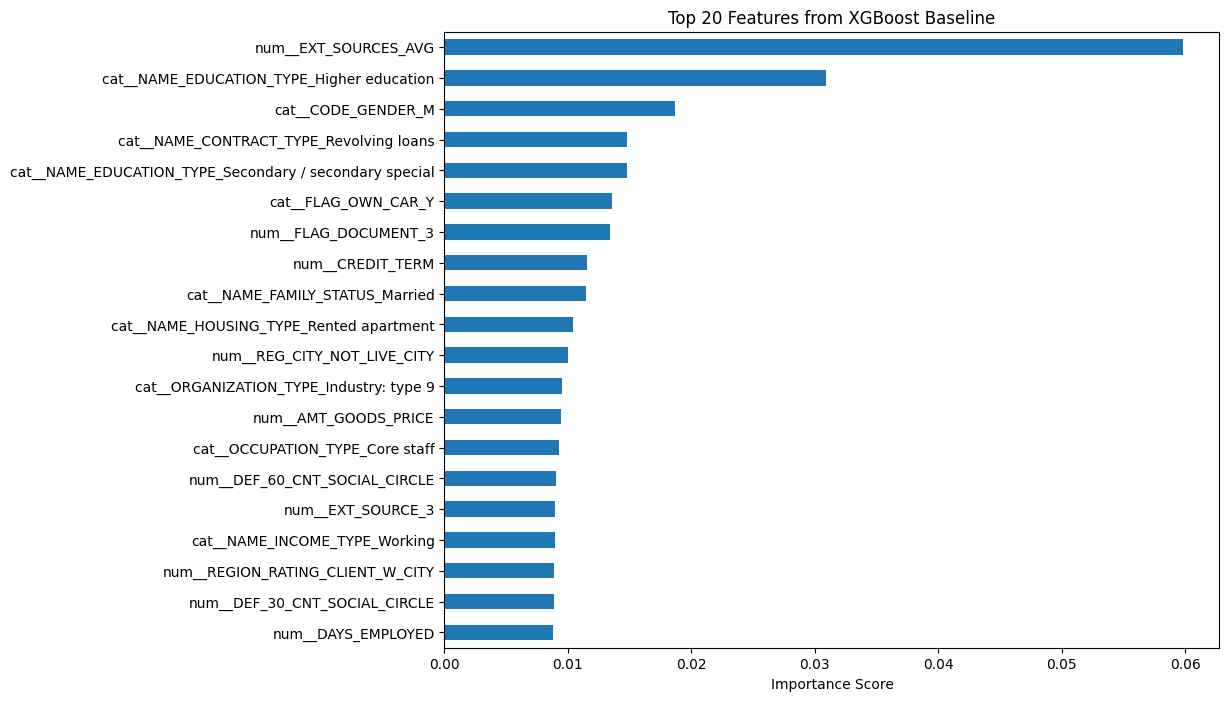

In [40]:
import matplotlib.pyplot as plt

# 1. Get the XGBoost pipeline from your results dictionary
best_xgb_pipe = results['XGBoost']['pipeline']

# 2. Extract feature names from the fitted preprocessor
feature_names = best_xgb_pipe.named_steps['pre'].get_feature_names_out()

# 3. Get the importance scores (Gain) from the model
importances = best_xgb_pipe.named_steps['model'].feature_importances_

# 4. Create a pandas Series for easy sorting and plotting
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 5. Plot the top 20 features
plt.figure(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh').invert_yaxis()
plt.title("Top 20 Features from XGBoost Baseline")
plt.xlabel("Importance Score")
plt.show()

In [41]:
feat_imp

num__EXT_SOURCES_AVG                                      0.059788
cat__NAME_EDUCATION_TYPE_Higher education                 0.030865
cat__CODE_GENDER_M                                        0.018676
cat__NAME_CONTRACT_TYPE_Revolving loans                   0.014774
cat__NAME_EDUCATION_TYPE_Secondary / secondary special    0.014749
                                                            ...   
cat__ORGANIZATION_TYPE_Industry: type 6                   0.000000
cat__ORGANIZATION_TYPE_Industry: type 8                   0.000000
cat__ORGANIZATION_TYPE_Mobile                             0.000000
cat__ORGANIZATION_TYPE_Religion                           0.000000
cat__ORGANIZATION_TYPE_XNA                                0.000000
Length: 185, dtype: float32

In [42]:
# 1. Get the raw names from your importance plot
raw_importance_names = feat_imp.head(20).index.tolist()

# 2. Clean names by removing 'num__' and 'cat__' prefixes
# This gets back to the base column name (or One-Hot name)
clean_names = [name.replace('num__', '').replace('cat__', '') for name in raw_importance_names]

# 3. Find which original columns these cleaned names belong to
selected_features = []
for clean_name in clean_names:
    for original_col in df.columns:
        # Check if the clean name starts with an original column name
        if clean_name.startswith(original_col):
            selected_features.append(original_col)
            break

# 4. Keep unique names only (One-Hot features will map to the same parent column)
selected_features = list(dict.fromkeys(selected_features))

# 5. Now you can safely filter your data


In [43]:
X = df[selected_features]
y = df['TARGET']
print(f"Refined Feature Count: {len(selected_features)}")
print(f"Top Original Features: {selected_features}")

Refined Feature Count: 19
Top Original Features: ['EXT_SOURCES_AVG', 'NAME_EDUCATION_TYPE', 'CODE_GENDER', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_DOCUMENT_3', 'CREDIT_TERM', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REG_CITY_NOT_LIVE_CITY', 'ORGANIZATION_TYPE', 'AMT_GOODS_PRICE', 'OCCUPATION_TYPE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_3', 'NAME_INCOME_TYPE', 'REGION_RATING_CLIENT', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DAYS_EMPLOYED']


In [44]:
from sklearn.model_selection import train_test_split

# Split using the 16 features identified in selected_features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

In [46]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()) # Handles outliers in AMT_CREDIT, etc.
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]), cat_cols)
])

In [47]:
scale_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1]))
# Define parameters to search
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1]
}

# Create a new pipeline for the search
search_pipe = Pipeline([('pre', preprocessor), ('model', XGBClassifier(scale_pos_weight=scale_weight))])

# Run the search
search = RandomizedSearchCV(search_pipe, param_grid, n_iter=5, scoring='roc_auc', cv=3)
search.fit(X_train, y_train)

# This is your "Champion" model
best_xgb = search.best_estimator_

In [48]:
best_xgb

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb.named_steps['model']), # Your tuned version
        ('lgbm', LGBMClassifier(scale_pos_weight=scale_weight)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=2000))
    ],
    voting='soft',
    weights=[2, 2, 1] 
)

# Final Training
final_production_model = Pipeline([('pre', preprocessor), ('model', voting_clf)])
final_production_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1480
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
# Get probabilities for the 'Default' class (column 1)
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test)

y_prob = final_production_model.predict_proba(X_test)[:, 1]

C:\Users\Manth\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [51]:
y_prob

array([0.380531  , 0.38874792, 0.76854115, ..., 0.30155859, 0.65738517,
       0.57621616], shape=(61503,))

In [52]:
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score

# Industry Standard Evaluation
auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1
ks = ks_2samp(y_prob[y_test == 0], y_prob[y_test == 1]).statistic

print(f"Final Model Gini: {gini:.4f}")
print(f"Final Model KS: {ks:.4f}")

Final Model Gini: 0.5177
Final Model KS: 0.3852


In [53]:
thresholds = [0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_temp = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_temp)
    # Calculate how many defaults we actually caught out of the total defaults
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) 
    
    print(f"Threshold {t}: Recall (Defaulters Caught) = {recall:.2%}")

Threshold 0.2: Recall (Defaulters Caught) = 97.36%
Threshold 0.3: Recall (Defaulters Caught) = 91.14%
Threshold 0.4: Recall (Defaulters Caught) = 80.77%
Threshold 0.5: Recall (Defaulters Caught) = 68.32%


## 9. SHAP explanation analysis
Install SHAP and prepare the preprocessed test set for model explanation.


 EVALUATION FOR THRESHOLD: 0.2
              precision    recall  f1-score   support

  No Default       0.99      0.17      0.28     56538
     Default       0.09      0.97      0.17      4965

    accuracy                           0.23     61503
   macro avg       0.54      0.57      0.23     61503
weighted avg       0.91      0.23      0.28     61503

CRITICAL METRIC: Recall for Defaults is 97.36%


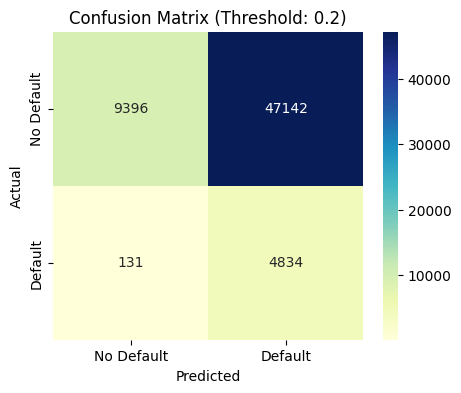


 EVALUATION FOR THRESHOLD: 0.3
              precision    recall  f1-score   support

  No Default       0.98      0.36      0.53     56538
     Default       0.11      0.91      0.20      4965

    accuracy                           0.41     61503
   macro avg       0.55      0.64      0.36     61503
weighted avg       0.91      0.41      0.50     61503

CRITICAL METRIC: Recall for Defaults is 91.14%


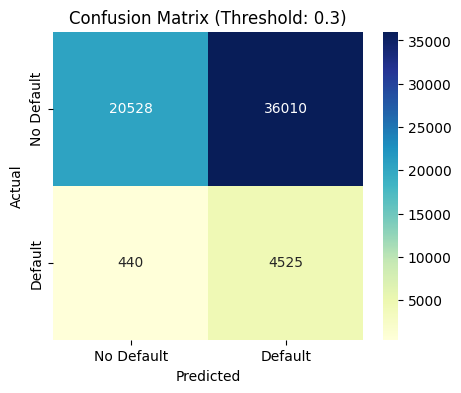

In [54]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# List of thresholds to compare
thresholds = [0.2, 0.3]

for t in thresholds:
    # Convert probabilities to binary predictions based on current threshold
    y_pred_t = (y_prob >= t).astype(int)
    
    print(f"\n" + "="*40)
    print(f" EVALUATION FOR THRESHOLD: {t}")
    print("="*40)
    
    # 1. Print the detailed report
    report = classification_report(y_test, y_pred_t, target_names=['No Default', 'Default'])
    print(report)
    
    # 2. Extract and print the specific Recall for Target 1 (Defaults)
    cm = confusion_matrix(y_test, y_pred_t)
    recall_default = cm[1,1] / (cm[1,1] + cm[1,0])
    print(f"CRITICAL METRIC: Recall for Defaults is {recall_default:.2%}")

    # 3. Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=['No Default', 'Default'], 
                yticklabels=['No Default', 'Default'])
    plt.title(f"Confusion Matrix (Threshold: {t})")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [55]:
# Assuming y_prob is already calculated from your final_production_model
threshold = 0.3
y_pred_03 = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report
print("--- FINAL CLASSIFICATION REPORT (THRESHOLD 0.3) ---")
print(classification_report(y_test, y_pred_03, target_names=['No Default', 'Default']))

--- FINAL CLASSIFICATION REPORT (THRESHOLD 0.3) ---
              precision    recall  f1-score   support

  No Default       0.98      0.36      0.53     56538
     Default       0.11      0.91      0.20      4965

    accuracy                           0.41     61503
   macro avg       0.55      0.64      0.36     61503
weighted avg       0.91      0.41      0.50     61503



In [56]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: C:\Users\Manth\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [57]:
# Prepare the preprocessed test set for SHAP explainability
data_preprocessed_raw = final_production_model.named_steps['pre'].transform(X_test)
feature_names = final_production_model.named_steps['pre'].get_feature_names_out()
if hasattr(data_preprocessed_raw, "toarray"):
    data_preprocessed_raw = data_preprocessed_raw.toarray()
X_test_preprocessed = pd.DataFrame(data_preprocessed_raw, columns=feature_names)

import shap
explainer = shap.TreeExplainer(final_production_model.named_steps['model'].estimators_[0])
shap_values = explainer.shap_values(X_test_preprocessed)

## 10. Export final model
Save the trained production pipeline for deployment and future inference.

In [58]:
import joblib
model_filename = 'final_credit_scoring_model.pkl'
joblib.dump(final_production_model, model_filename)
print(f"Success! Your final model has been saved as: {model_filename}")

Success! Your final model has been saved as: final_credit_scoring_model.pkl
